In [1]:
from tifffile import imread

from matplotlib import pyplot as plt

import numpy as np

from skimage.morphology import h_maxima

from spot_detection_utils import subpixel_localization, get_spot
from skimage.measure import regionprops

In [2]:
image = imread('/tungstenfs/scratch/gchao/bamfaile/Analysis/TUBB2B-KI/Batch20230223/D21/Denoised/100tp_561-100-50ms-1000g_4_conf561_merged.tif')

In [3]:
denoised_img = image[:, 0]
raw_img = image[:, 1]

In [4]:
mask = imread('/tungstenfs/scratch/gchao/bamfaile/Analysis/TUBB2B-KI/Batch20230223/D21/ROIs/ROIs_as_mask_BIOP/100tp_561-100-50ms-1000g_4_conf561_merged_ROI1-5.tif')

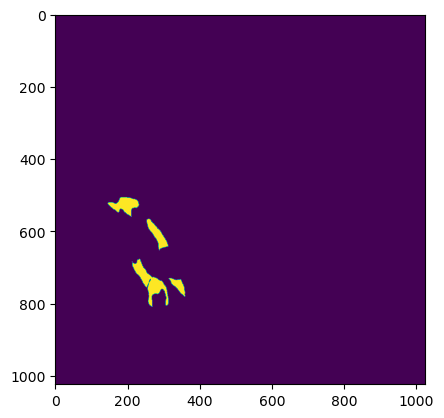

In [5]:
plt.imshow(mask > 0)

In [6]:
# Mask out foreground (mask > 0) --> go from instance segmentation to semantic segmentation (fg vs bg)
masked_cells = denoised_img * (mask > 0)

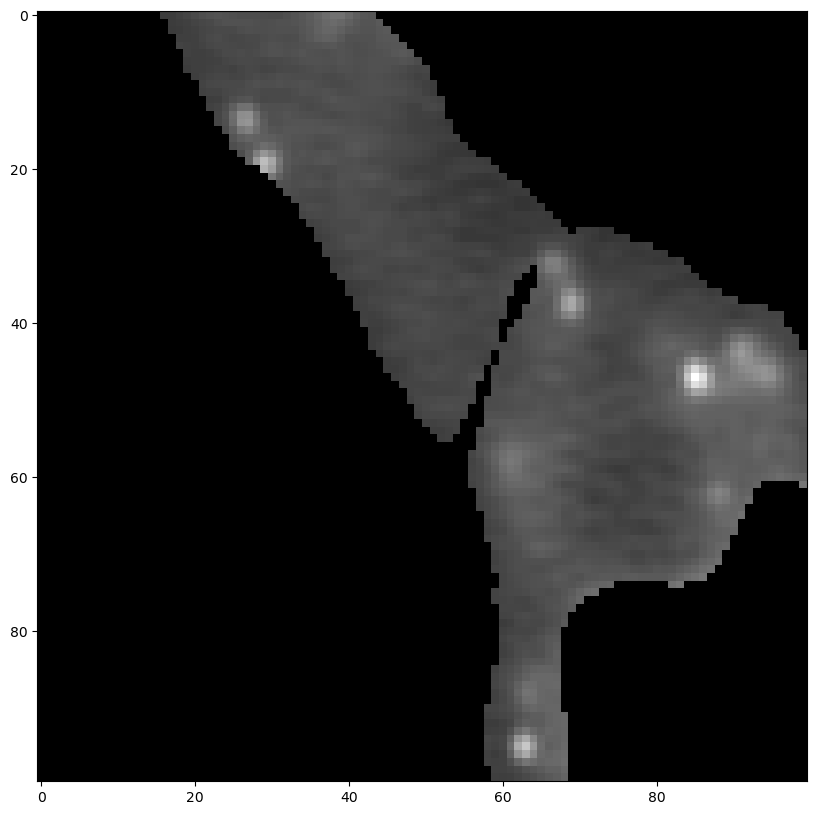

In [7]:
frame = 10
plt.figure(figsize=(10,10))
plt.imshow(masked_cells[frame, 700:800,200:300], cmap='gray')

In [8]:
from skimage.morphology import disk

In [9]:
# TODO: How to choose threshold? Is standard deviation a good choice?
threshold = int(np.std(denoised_img[frame, mask > 0]))
spots = h_maxima(image=denoised_img[frame], footprint=disk(1), h=threshold)
spots = spots * (mask > 0)

In [10]:
from matplotlib.colors import ListedColormap
spot_cmap = ListedColormap([[0, 0, 0, 0], [1, 0, 0, 1]])

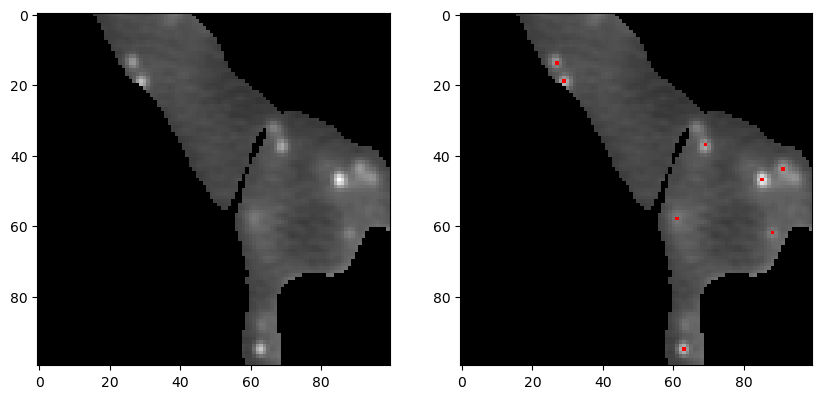

In [11]:
plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
plt.imshow(masked_cells[frame, 700:800,200:300], cmap='gray')
plt.subplot(1,2,2)
plt.imshow(masked_cells[frame, 700:800,200:300], cmap='gray')
plt.imshow(spots[700:800, 200:300], cmap=spot_cmap)

In [12]:
# Assign spots to ROIs
spots_per_roi = []
roi_labels = list(filter(None, np.unique(mask)))

for label_id in roi_labels:
    spots_per_roi.append(np.where(spots * (mask == label_id)))

In [13]:
roi_labels

[1, 2, 3, 4, 5]

In [14]:
spots_per_roi

[(array([697, 714, 719]), array([240, 227, 229])),
 (array([737, 744, 747, 758, 762, 795, 803]),
  array([269, 291, 285, 261, 288, 263, 309])),
 (array([517, 524, 525, 536]), array([186, 213, 220, 195])),
 (array([594, 599, 602, 608, 614]), array([272, 284, 272, 278, 291])),
 (array([744, 750]), array([345, 343]))]

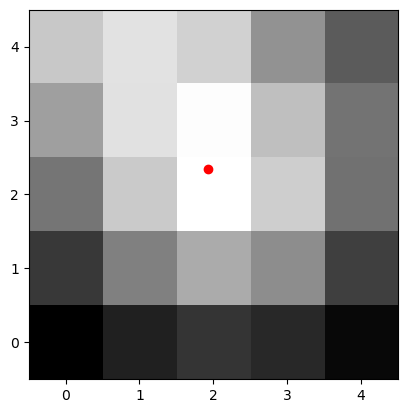

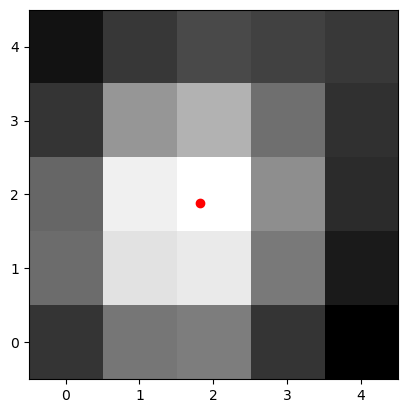

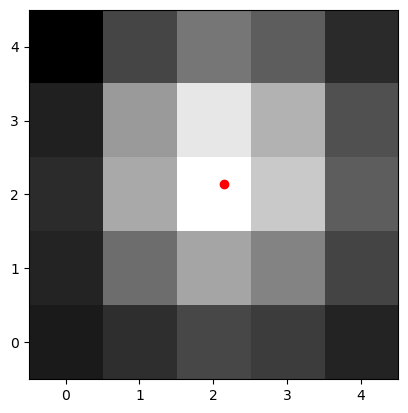

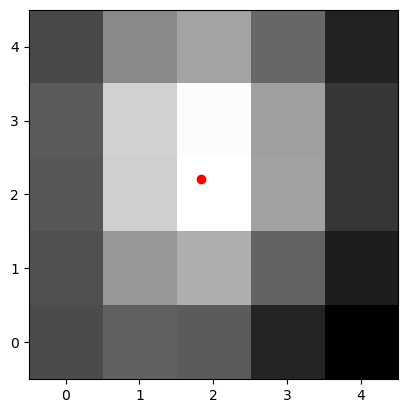

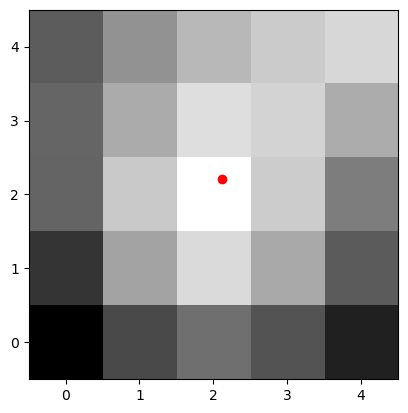

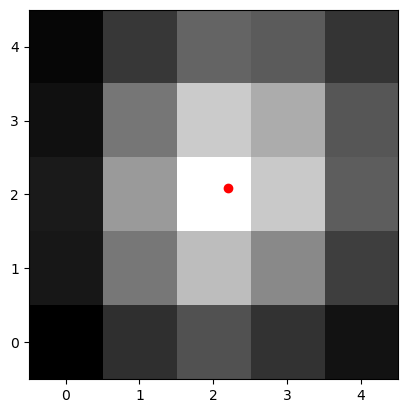

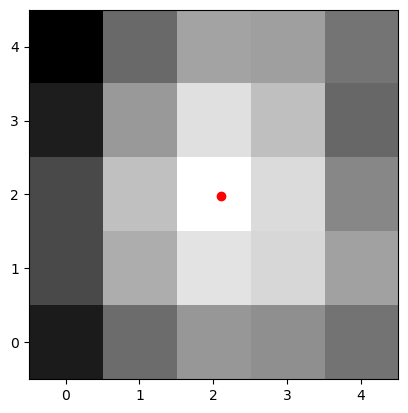

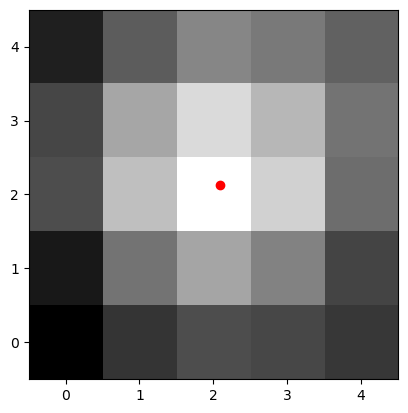

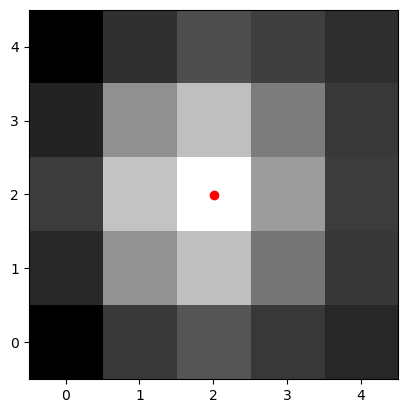

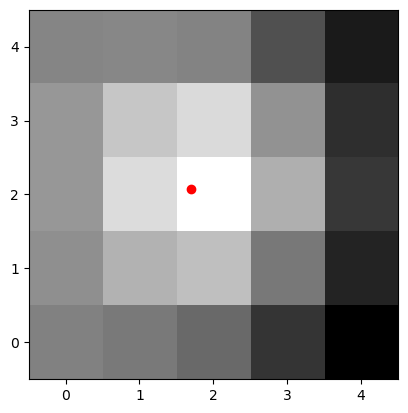

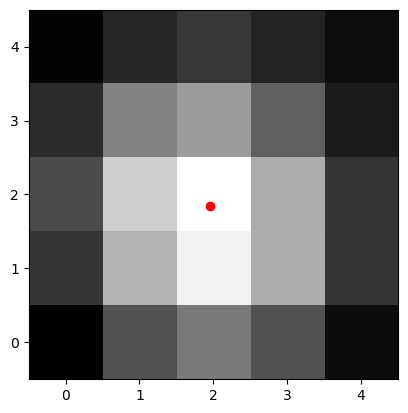

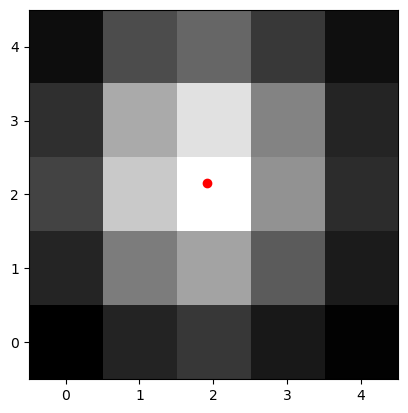

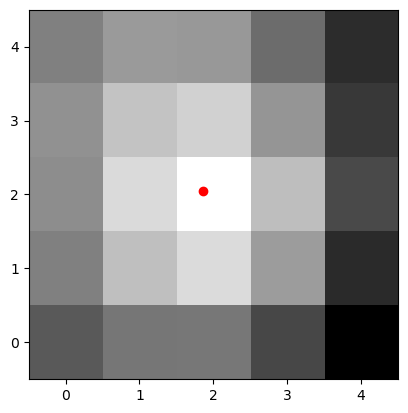

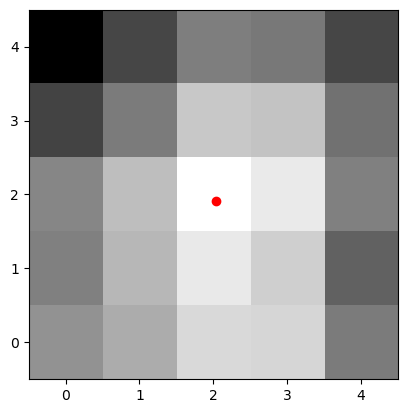

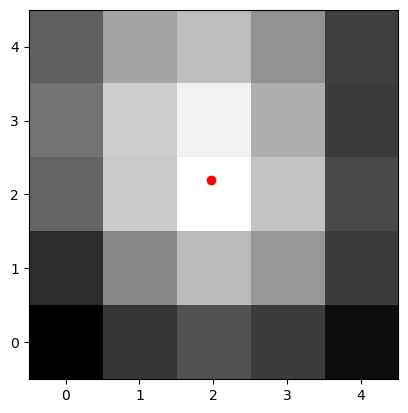

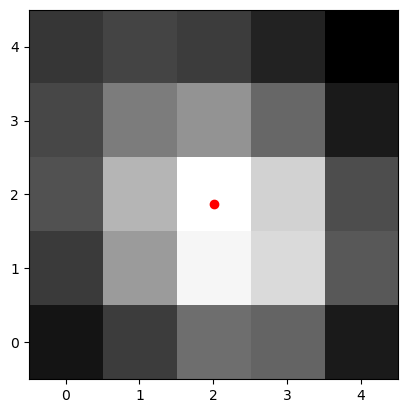

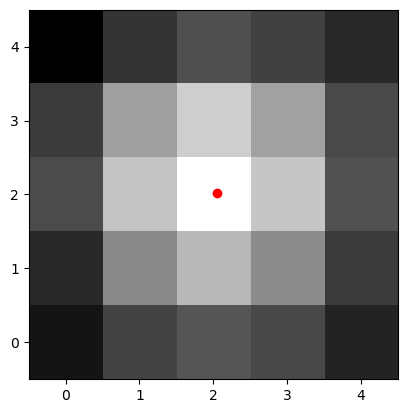

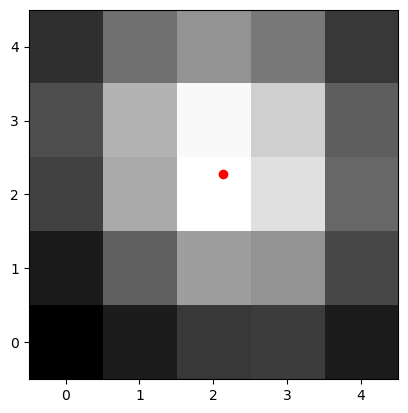

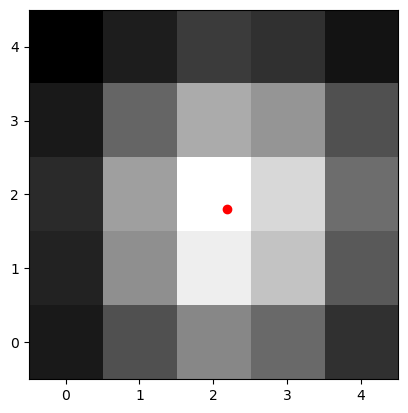

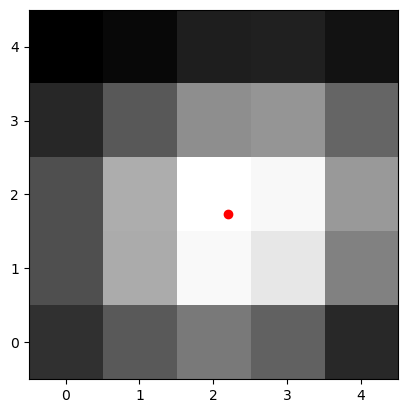

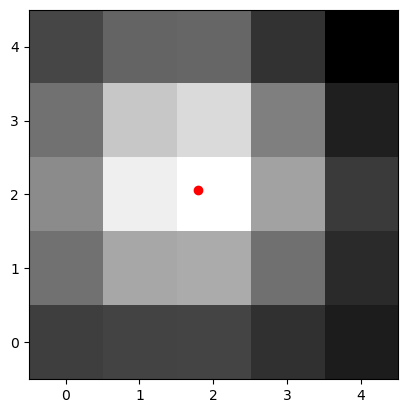

In [15]:
# subpixel localization of spots and visualization
spot_size = 3

subpix_spots = {}
for roi_id, (y_coords, x_coords) in zip(roi_labels, spots_per_roi):
    subpix_spots[roi_id] = []
    for y, x in zip(y_coords, x_coords):
        spot_img, start_y, start_x = get_spot(denoised_img[frame], [y, x], size=5)
        y_loc, x_loc = subpixel_localization(spot_img)
        plt.imshow(spot_img, cmap='gray', origin='lower')
        plt.plot(x_loc, y_loc, 'ro')
        plt.show()
        subpix_spots[roi_id].append([start_y + y_loc, start_x + x_loc])


In [16]:
features = regionprops(mask)

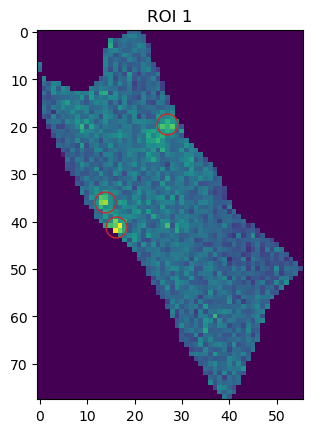

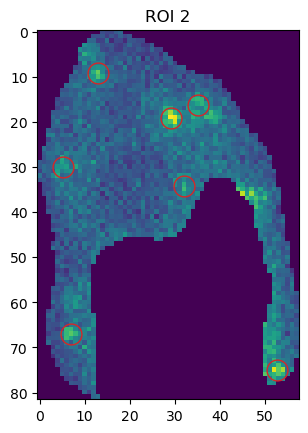

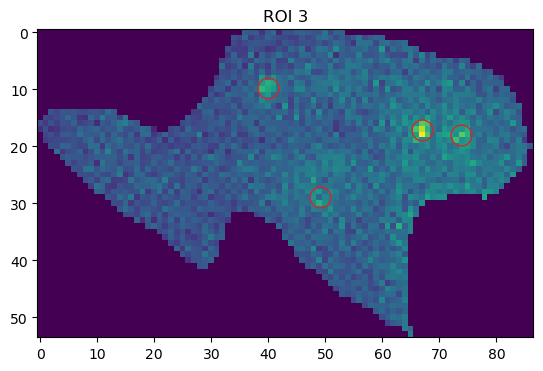

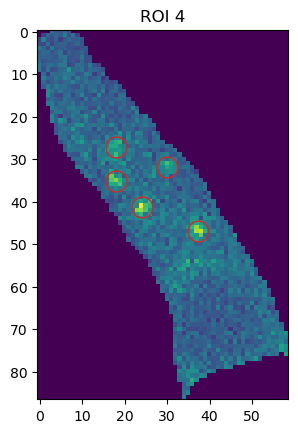

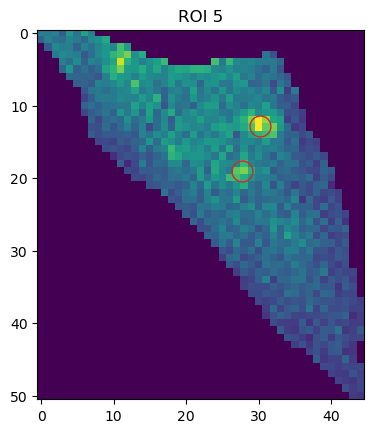

In [17]:
# Overlay subpixel localized spots on raw image frame.
marker_style = dict(color='tab:red', linestyle=':', marker='o',
                    markersize=15, markerfacecoloralt='tab:red')

for prop in features:
    box = prop.bbox
    plt.imshow((raw_img[frame] * (mask == prop.label))[box[0]:box[2], box[1]:box[3]])
    for y, x in subpix_spots[prop.label]:
        plt.plot(x - box[1], y- box[0], fillstyle='none', **marker_style)

    plt.title(f'ROI {prop.label}')
    plt.show()

In [18]:
import pandas as pd

In [19]:
dfs = []
for roi_id in subpix_spots:
    spot_df = pd.DataFrame(subpix_spots[roi_id], columns=['y', 'x'])
    spot_df['roi_id'] = roi_id
    spot_df['frame'] = frame

    dfs.append(spot_df)

spots_for_frame_df = pd.concat(dfs, ignore_index=True)
spots_for_frame_df = spots_for_frame_df.reindex(columns=['frame', 'roi_id', 'x', 'y'])

In [20]:
spots_for_frame_df

,frame,roi_id,x,y
0,10,1,239.927398,697.349833
1,10,1,226.823300,713.883927
2,10,1,229.137965,719.144774
3,10,2,268.830631,737.209397
4,10,2,291.121017,744.215927
5,10,2,285.194435,747.091166
6,10,2,261.109188,757.981634
7,10,2,288.083264,762.122572
8,10,2,263.004897,794.998118
9,10,2,308.698342,803.071790
